# 🧠 Exploration du modèle YOLO pré-entraîné (avant fine-tuning)

**Objectif** : comprendre ce que sait déjà faire un YOLO entraîné sur COCO
*avant* qu'on le spécialise sur `smoke`/`fire`, et pourquoi le **transfer learning**
est une stratégie efficace ici plutôt que d'entraîner from scratch.

Ce notebook répond à 3 questions :
1. Qu'est-ce que le modèle sait détecter nativement (80 classes COCO) ?
2. Quelle est son architecture, sa taille, sa vitesse ?
3. Pourquoi ses features apprises (bords, textures, formes) sont-elles réutilisables pour la fumée/le feu ?


In [1]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

MODEL_VARIANTS = ["yolov8n.pt", "yolov8s.pt", "yolov8m.pt"]  # nano / small / medium
model = YOLO(MODEL_VARIANTS[0])  # on démarre avec le plus léger pour le prototypage

## 1. Classes que le modèle connaît déjà (COCO, 80 classes)

In [2]:
coco_classes = model.names
print(f"Nombre de classes COCO : {len(coco_classes)}")
for i, name in coco_classes.items():
    print(f"{i:3d} - {name}")


Nombre de classes COCO : 80
  0 - person
  1 - bicycle
  2 - car
  3 - motorcycle
  4 - airplane
  5 - bus
  6 - train
  7 - truck
  8 - boat
  9 - traffic light
 10 - fire hydrant
 11 - stop sign
 12 - parking meter
 13 - bench
 14 - bird
 15 - cat
 16 - dog
 17 - horse
 18 - sheep
 19 - cow
 20 - elephant
 21 - bear
 22 - zebra
 23 - giraffe
 24 - backpack
 25 - umbrella
 26 - handbag
 27 - tie
 28 - suitcase
 29 - frisbee
 30 - skis
 31 - snowboard
 32 - sports ball
 33 - kite
 34 - baseball bat
 35 - baseball glove
 36 - skateboard
 37 - surfboard
 38 - tennis racket
 39 - bottle
 40 - wine glass
 41 - cup
 42 - fork
 43 - knife
 44 - spoon
 45 - bowl
 46 - banana
 47 - apple
 48 - sandwich
 49 - orange
 50 - broccoli
 51 - carrot
 52 - hot dog
 53 - pizza
 54 - donut
 55 - cake
 56 - chair
 57 - couch
 58 - potted plant
 59 - bed
 60 - dining table
 61 - toilet
 62 - tv
 63 - laptop
 64 - mouse
 65 - remote
 66 - keyboard
 67 - cell phone
 68 - microwave
 69 - oven
 70 - toaster
 

## 2. Architecture et taille du modèle

In [5]:
model.info(detailed=False)  # affiche les informations détaillées du modèle

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8550912)

In [6]:
# Comparatif des variantes de taille (nano/small/medium) : compromis précision <-> vitesse
comparison_rows = []
for variant in MODEL_VARIANTS:
    m = YOLO(variant)
    n_params = sum(p.numel() for p in m.model.parameters())
    comparison_rows.append({
        "modèle": variant,
        "paramètres (M)": round(n_params / 1e6, 2),
    })
comp_df = pd.DataFrame(comparison_rows)
comp_df


,modèle,paramètres (M)
0,yolov8n.pt,3.16
1,yolov8s.pt,11.17
2,yolov8m.pt,25.90


## 3. Test zero-shot sur une image du dataset (avant fine-tuning)

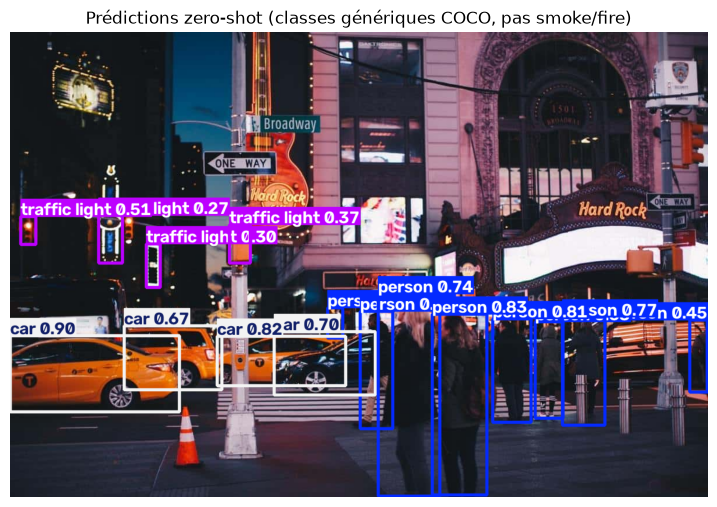

Objets détectés : ['car', 'person', 'car', 'person', 'person', 'person', 'car', 'car', 'person', 'person', 'traffic light', 'person', 'traffic light', 'traffic light', 'traffic light', 'person']


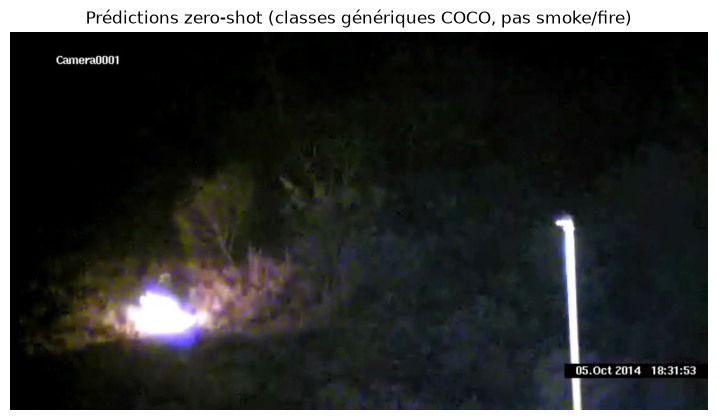

Objets détectés : []


In [16]:
# Remplace par le chemin d'une image de ton dataset une fois téléchargé (data/images/train/...)
sample_images = ["../data/exemple.jpg", "../data/images/train/AoF00001.jpg"] # <- à adapter

for sample_image in sample_images:
    if Path(sample_image).exists():
        result = model.predict(sample_image, conf=0.25, verbose=False)[0]
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.imshow(result.plot()[..., ::-1])
        ax.set_title("Prédictions zero-shot (classes génériques COCO, pas smoke/fire)")
        ax.axis("off")
        plt.show()
        print(f"Objets détectés : {[model.names[int(b.cls)] for b in result.boxes]}")
    else:
        print("Renseigne le chemin d'une image existante de ton dataset ci-dessus.")


**Interprétation** : sur une image contenant de la fumée, le modèle zero-shot
ne produira **aucune boîte `smoke`** (classe inexistante dans COCO) — au mieux il
détectera des objets contextuels (personne, véhicule, bâtiment). C'est le point de
départ que le fine-tuning va faire évoluer.

## 4. Benchmark de vitesse (FPS) — avant optimisation

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device utilisé : {device}")

for sample_image in sample_images:
    if Path(sample_image).exists():
        # warm-up
        for _ in range(3):
            model.predict(sample_image, device=device, verbose=False)

        n_runs = 20
        start = time.time()
        for _ in range(n_runs):
            model.predict(sample_image, device=device, verbose=False)
        elapsed = time.time() - start
        fps = n_runs / elapsed
        print(f"Latence moyenne : {elapsed/n_runs*1000:.1f} ms/image  |  ~{fps:.1f} FPS sur {device}")
    else:
        print("Renseigne une image valide pour lancer le benchmark.")


Device utilisé : cpu
Latence moyenne : 39.0 ms/image  |  ~25.6 FPS sur cpu
Latence moyenne : 33.7 ms/image  |  ~29.7 FPS sur cpu


**Pourquoi c'est important** : le déploiement temps réel (webcam/RTSP)
n'est utilisable que si le FPS dépasse un seuil raisonnable (idéalement > 15-20 FPS).
Si le FPS mesuré ici est trop bas, options : modèle plus petit (`yolov8n`), export
ONNX/TensorRT, réduction de `imgsz`, ou inférence sur GPU dédié.